# GNN training with k-fold cross-validation

Replaces the single 80/10/10 train/validation/test split with grouped k-fold cross-validation. Materials (not individual graphs/polymorphs) are what get assigned to folds, mirroring the leakage-prevention logic already used in `split_dataset`.

**Workflow -- one fold per kernel session.** Each fold trains from a completely fresh process, so nothing (CUDA memory, optimizer state, RNG state, leftover Python objects) can carry over between folds:

1. Run every cell down through **"Compute or load k-fold splits"** once. This computes the fold assignment and saves it to disk -- every later session reuses the exact same split instead of recomputing it, so it can't silently shift if `n_splits` changes later.
2. Set `fold_idx_to_run = 0` in the next cell, then run down through **"Train the selected fold"**. This trains fold 0 and saves its model and results to disk.
3. **Restart the kernel.** Set `fold_idx_to_run = 1`, run the same cells again (the raw dataset load is cached, so this is fast). Repeat through `fold_idx_to_run = n_splits - 1`.
4. Once every fold has a saved result, restart once more and run **"Aggregate cross-validation results"** onward -- this reads all `n_splits` results back from disk rather than relying on anything still in memory.

To automate the restart-and-rerun cycle instead of doing it by hand, `papermill this_notebook.ipynb out_fold_{k}.ipynb -p fold_idx_to_run k` (run once per fold) executes each pass in its own fresh process automatically.

What's different from the original single-split notebook:
- No fixed test set: every material is held out exactly once, across `n_splits` models
- Standardization is computed per fold, from that fold's training materials only (val statistics never leak into scaling)
- The fold split is computed once and persisted to disk
- Any leftover checkpoint for a fold is deleted before training starts, so `mode='train'` always means a genuinely fresh model, regardless of what ran in this folder before
- The final uncertainty estimate uses genuine out-of-fold residuals, reassembled from each fold's saved predictions
- An optional final section refits one deployable model on the full dataset

# Load libraries and set device up

In [2]:
import numpy    as np
import torch.nn as nn
import json
import os
import torch

import libraries.model   as clm
import libraries.dataset as cld

from torch_geometric.loader import DataLoader

# Checking if pytorch can run in GPU, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/claudio/cibran/Work/UCL/ml-phasetransitions/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
target_folder = 'model'

In [4]:
files_names = {
    'dataset':            f'{target_folder}/dataset.pt',
    'dataset_parameters': f'{target_folder}/dataset_parameters.json',
    'model_parameters':   f'{target_folder}/model_parameters.json',
    'cv_summary':         f'{target_folder}/cv_summary.json',
    'uncertainty_data':   f'{target_folder}/uncertainty_data.json'
}
cld.save_json(files_names, f'{target_folder}/files_names.json')


def get_fold_files_names(fold_idx):
    """Per-fold file paths, namespaced by n_splits so a different fold count
    can never collide with a previous configuration's checkpoints/results.

    Args:
        fold_idx (int): Index of the fold.

    Returns:
        dict: File paths for this fold's data, checkpoint, and saved results.
    """
    tag = f'n{n_splits}_fold{fold_idx}'
    return {
        'train_dataset_std': f'{target_folder}/{tag}_train_dataset_std.pt',
        'val_dataset_std':   f'{target_folder}/{tag}_val_dataset_std.pt',
        'std_parameters':    f'{target_folder}/{tag}_standardized_parameters.json',
        'model':             f'{target_folder}/{tag}_model.pt',
        'result':            f'{target_folder}/{tag}_result.json',
        'oof':               f'{target_folder}/{tag}_oof.json'
    }

# Define parameters

In [5]:
n_epochs =      400
batch_size =    128
learning_rate = 0.0001
dropout =       0.2
patience =      n_epochs
delta =         2
n_splits =      10   # number of folds for k-fold cross-validation

model_parameters = {
    'n_epochs':      n_epochs,
    'batch_size':    batch_size,
    'learning_rate': learning_rate,
    'dropout':       dropout,
    'patience':      patience,
    'delta':         delta,
    'n_splits':      n_splits
}
cld.save_json(model_parameters, files_names['model_parameters'])

# Generate or load graph database for training

In [6]:
# Try loading the previously generated raw dataset directly, else generate it
if not os.path.exists(files_names['dataset']):
    cld.generate_dataset('datasets/phonon-database',
                         targets=['free-energy'],
                         data_folder=target_folder)

dataset = torch.load(files_names['dataset'], weights_only=False)

# Material label is the first token of data.label (e.g. polymorphs share a material label)
material_labels_all = np.array([data.label.split()[0] for data in dataset])
print(f'Loaded {len(dataset)} graphs from {len(np.unique(material_labels_all))} unique materials')

Loaded 46571 graphs from 5403 unique materials


# Compute or load k-fold splits

Groups graphs by material label and assigns whole materials to folds, so every polymorph of a given material stays together -- the same rule `split_dataset` already used to keep train/val/test from leaking.

This is computed once and saved to `kfold_splits_n{n_splits}.json`. Every later kernel session (one per fold, per the workflow above) loads the exact same assignment back from disk rather than recomputing it, so the fold boundaries can never shift between sessions.

In [7]:
def get_material_kfold_splits(material_labels, n_splits, seed=42):
    """Group graphs by material label and build k roughly-balanced folds.

    Keeps every polymorph of a given material in the same fold, mirroring the
    leakage-prevention logic already used in libraries.dataset.split_dataset.

    Args:
        material_labels (np.ndarray): Material label (first token of data.label) per graph.
        n_splits         (int):       Number of folds (k).
        seed              (int):      Random seed for reproducible fold assignment.

    Returns:
        list: List of (train_labels, val_labels) tuples, one per fold -- arrays of unique
            material labels assigned to that fold's train/validation split.
    """
    unique_labels = np.unique(material_labels)

    rng = np.random.RandomState(seed)
    shuffled_labels = unique_labels.copy()
    rng.shuffle(shuffled_labels)

    fold_label_groups = np.array_split(shuffled_labels, n_splits)

    splits = []
    for fold_idx in range(n_splits):
        val_labels   = fold_label_groups[fold_idx]
        train_labels = np.concatenate([g for i, g in enumerate(fold_label_groups) if i != fold_idx])
        splits.append((train_labels, val_labels))
    return splits


splits_file = f'{target_folder}/kfold_splits_n{n_splits}.json'

if os.path.exists(splits_file):
    with open(splits_file) as f:
        saved_splits = json.load(f)
    assert saved_splits['n_splits'] == n_splits, "saved split file doesn't match the current n_splits"
    fold_splits = [(np.array(fold['train_labels']), np.array(fold['val_labels']))
                  for fold in saved_splits['folds']]
    print(f'Loaded existing fold split from {splits_file}')
else:
    fold_splits = get_material_kfold_splits(material_labels_all, n_splits)
    saved_splits = {
        'n_splits': n_splits,
        'seed': 42,
        'folds': [{'train_labels': tl.tolist(), 'val_labels': vl.tolist()} for tl, vl in fold_splits]
    }
    with open(splits_file, 'w') as f:
        json.dump(saved_splits, f)
    print(f'Computed a new fold split and saved it to {splits_file}')

for fold_idx, (train_labels, val_labels) in enumerate(fold_splits):
    print(f'Fold {fold_idx + 1}/{n_splits}: {len(train_labels)} train materials, {len(val_labels)} val materials')

Loaded existing fold split from model/kfold_splits_n10.json
Fold 1/10: 4862 train materials, 541 val materials
Fold 2/10: 4862 train materials, 541 val materials
Fold 3/10: 4862 train materials, 541 val materials
Fold 4/10: 4863 train materials, 540 val materials
Fold 5/10: 4863 train materials, 540 val materials
Fold 6/10: 4863 train materials, 540 val materials
Fold 7/10: 4863 train materials, 540 val materials
Fold 8/10: 4863 train materials, 540 val materials
Fold 9/10: 4863 train materials, 540 val materials
Fold 10/10: 4863 train materials, 540 val materials


# Select which fold to train in this kernel session

Set this, then run every cell below through "Train the selected fold". Restart the kernel and change this value to move to the next fold.

In [7]:
fold_idx_to_run = 0

assert 0 <= fold_idx_to_run < n_splits, f"fold_idx_to_run must be between 0 and {n_splits - 1}"

# Train the selected fold

Standardizes using only this fold's training materials, trains a fresh model with early stopping, reloads the best checkpoint, evaluates on the held-out fold, and saves the result to disk.

Note: this fold's held-out materials serve both as the early-stopping signal and the reported fold metric -- the standard simplification for k-fold CV. A stricter nested CV would use a separate inner split for stopping, at the cost of roughly k x more training runs.


===== Fold 1/10 =====
Epoch: 20, Train MAE: 50.2206, Val MAE: 51.6714
Epoch: 40, Train MAE: 37.8971, Val MAE: 39.0455
Epoch: 60, Train MAE: 32.1273, Val MAE: 36.3886
Epoch: 80, Train MAE: 29.1399, Val MAE: 32.9853
Epoch: 100, Train MAE: 27.6641, Val MAE: 31.2441
Epoch: 120, Train MAE: 25.8517, Val MAE: 32.3370
Epoch: 140, Train MAE: 24.5804, Val MAE: 30.5668
Epoch: 160, Train MAE: 24.0047, Val MAE: 27.1193
Epoch: 180, Train MAE: 22.9779, Val MAE: 25.8556
Epoch: 200, Train MAE: 22.1787, Val MAE: 25.8095
Epoch: 220, Train MAE: 21.2037, Val MAE: 26.3115
Epoch: 240, Train MAE: 20.9599, Val MAE: 24.8088
Epoch: 260, Train MAE: 19.9885, Val MAE: 23.8458
Epoch: 280, Train MAE: 19.4206, Val MAE: 24.5523
Epoch: 300, Train MAE: 19.1272, Val MAE: 22.3305
Epoch: 320, Train MAE: 18.5722, Val MAE: 23.3777
Epoch: 340, Train MAE: 18.0121, Val MAE: 23.8722
Epoch: 360, Train MAE: 17.5351, Val MAE: 22.8463
Epoch: 380, Train MAE: 17.0768, Val MAE: 24.3511
Epoch: 400, Train MAE: 16.8606, Val MAE: 22.6801
F

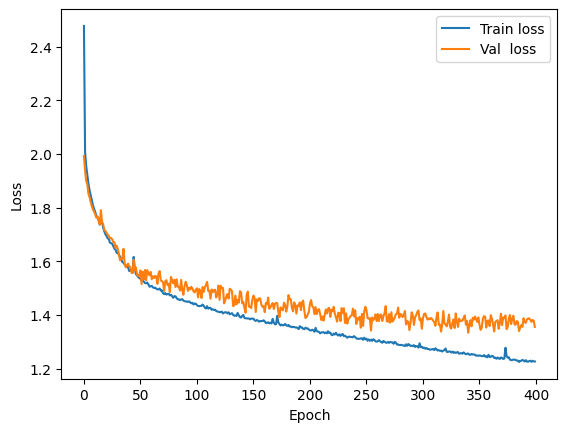

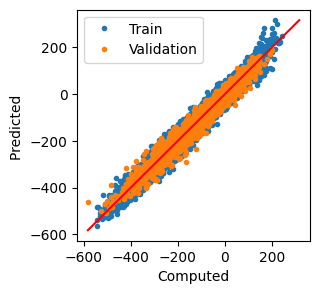


Fold 1/10 done and saved.
Restart the kernel, set fold_idx_to_run = 1, and run again.


In [8]:
fold_idx = fold_idx_to_run
train_labels, val_labels = fold_splits[fold_idx]
fold_files_names = get_fold_files_names(fold_idx)

if os.path.exists(fold_files_names['result']):
    print(f'Note: fold {fold_idx} already has a saved result - this run will overwrite it.')

print(f'\n===== Fold {fold_idx + 1}/{n_splits} =====')

# Split this fold's raw graphs by material label
fold_train_dataset = cld.get_datasets(train_labels, material_labels_all, dataset)
fold_val_dataset   = cld.get_datasets(val_labels,   material_labels_all, dataset)

# Standardize using ONLY this fold's training data, then apply those same
# parameters to the held-out fold - val statistics never leak into scaling.
# standardize_dataset already clones internally; standardize_dataset_from_keys
# mutates in place, so the val split is cloned first to avoid touching the
# shared graph objects other folds use as training data.
fold_train_dataset_std, fold_std_parameters = cld.standardize_dataset(
    fold_train_dataset, transformation='inverse-quadratic'
)
fold_val_dataset_std = cld.standardize_dataset_from_keys(
    [data.clone() for data in fold_val_dataset], fold_std_parameters
)

#torch.save(fold_train_dataset_std, fold_files_names['train_dataset_std'])
#torch.save(fold_val_dataset_std,   fold_files_names['val_dataset_std'])
cld.save_json(fold_std_parameters, fold_files_names['std_parameters'])

fold_target_factor = np.array(fold_std_parameters['target_std']) / fold_std_parameters['scale']

fold_train_loader = DataLoader(fold_train_dataset_std, batch_size=batch_size, shuffle=False, pin_memory=True)
fold_val_loader   = DataLoader(fold_val_dataset_std,   batch_size=batch_size, shuffle=False, pin_memory=True)

n_node_features = fold_train_dataset_std[0].num_node_features

criterion = torch.nn.MSELoss()  # MSELoss is by default defined as the mean within the batch

model = clm.load_model(n_node_features, dropout, device, model_name=fold_files_names['model'], mode='train')

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

fold_train_losses = []
fold_val_losses   = []
for epoch in range(n_epochs):
    train_loss, train_predictions, train_ground_truths = clm.train(model, criterion, fold_train_loader,
                                                                   fold_target_factor,
                                                                   fold_std_parameters['target_mean'],
                                                                   optimizer)
    val_loss,   val_predictions,   val_ground_truths   = clm.test(model, criterion, fold_val_loader,
                                                                   fold_target_factor,
                                                                   fold_std_parameters['target_mean'])

    # Convert to original units
    train_loss = np.sum(np.sqrt(train_loss) * fold_target_factor)
    val_loss   = np.sum(np.sqrt(val_loss)   * fold_target_factor)

    fold_train_losses.append(train_loss)
    fold_val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch: {epoch + 1}, Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}')

val_loss, val_predictions, val_ground_truths = clm.test(model, criterion, fold_val_loader,
                                                         fold_target_factor,
                                                         fold_std_parameters['target_mean'])
val_loss = np.sum(np.sqrt(val_loss) * fold_target_factor)

print(f'Fold {fold_idx + 1}/{n_splits} best Val MAE: {val_loss:.4f}')

cld.losses_plot(train_losses=fold_train_losses, val_losses=fold_val_losses, to_log=True)
cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                validation=np.array([val_ground_truths, val_predictions]))

# Save this fold's result and out-of-fold predictions to disk - the
# aggregation step (run later, in a separate session, after every fold is
# done) reads these back rather than relying on anything still in memory
fold_result = {
    'fold':           fold_idx,
    'n_train_graphs': len(fold_train_dataset),
    'n_val_graphs':   len(fold_val_dataset),
    'val_mae':        float(val_loss),
    'train_losses':   [float(x) for x in fold_train_losses],
    'val_losses':     [float(x) for x in fold_val_losses]
}
with open(fold_files_names['result'], 'w') as f:
    json.dump(fold_result, f)

oof_data = {
    'labels':        [f'{data.label} {data.y[0]}' for data in fold_val_dataset_std],
    'predictions':   np.asarray(val_predictions).tolist(),
    'ground_truths': np.asarray(val_ground_truths).tolist()
}
with open(fold_files_names['oof'], 'w') as f:
    json.dump(oof_data, f)

print(f"\nFold {fold_idx + 1}/{n_splits} done and saved.")
if fold_idx + 1 < n_splits:
    print(f"Restart the kernel, set fold_idx_to_run = {fold_idx + 1}, and run again.")
else:
    print("All folds done - restart the kernel once more and run the aggregation section below.")

# Free up memory regardless (harmless if you are restarting the kernel anyway,
# and a safety net if you choose to run another fold in this same session)
del model, optimizer, fold_train_loader, fold_val_loader
if device.type == 'cuda':
    torch.cuda.empty_cache()

---
**Restart the kernel now.** Either set `fold_idx_to_run` to the next fold and rerun the cells above, or -- once every fold from `0` to `n_splits - 1` has a saved result -- continue to the aggregation section below.

---

# Aggregate cross-validation results

Run this only after every fold has a saved result on disk.

K-fold CV MAE: 22.2092 +/- 0.9591
  Fold 1: 22.6801  (41706 train / 4865 val graphs)
  Fold 2: 21.1430  (41944 train / 4627 val graphs)
  Fold 3: 23.4204  (41860 train / 4711 val graphs)
  Fold 4: 20.1819  (42028 train / 4543 val graphs)
  Fold 5: 21.7195  (41622 train / 4949 val graphs)
  Fold 6: 23.1882  (42105 train / 4466 val graphs)
  Fold 7: 22.7350  (42119 train / 4452 val graphs)
  Fold 8: 22.1191  (41916 train / 4655 val graphs)
  Fold 9: 23.0277  (42021 train / 4550 val graphs)
  Fold 10: 21.8767  (41818 train / 4753 val graphs)


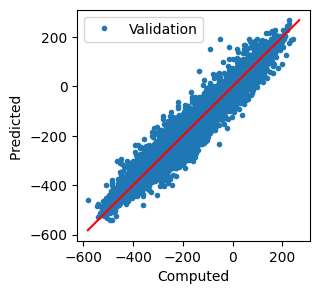

In [8]:
missing = [k for k in range(n_splits) if not os.path.exists(get_fold_files_names(k)['result'])]
if missing:
    raise RuntimeError(f'Missing saved results for fold(s) {missing}. Train each one '
                       f'(set fold_idx_to_run and restart the kernel) before aggregating.')

fold_results       = []
oof_labels         = []
oof_predictions    = []
oof_ground_truths  = []
for k in range(n_splits):
    fold_paths = get_fold_files_names(k)
    with open(fold_paths['result']) as f:
        fold_results.append(json.load(f))
    with open(fold_paths['oof']) as f:
        oof_data = json.load(f)
    oof_labels.extend(oof_data['labels'])
    oof_predictions.append(np.array(oof_data['predictions']))
    oof_ground_truths.append(np.array(oof_data['ground_truths']))

oof_predictions   = np.concatenate(oof_predictions)
oof_ground_truths = np.concatenate(oof_ground_truths)

fold_maes = np.array([r['val_mae'] for r in fold_results])
print(f'K-fold CV MAE: {fold_maes.mean():.4f} +/- {fold_maes.std():.4f}')
for r in fold_results:
    print(f"  Fold {r['fold'] + 1}: {r['val_mae']:.4f}  ({r['n_train_graphs']} train / {r['n_val_graphs']} val graphs)")

# Every material was validated exactly once, by a model that never trained on
# it - so this parity plot covers the full dataset without needing a separate
# held-out test split
cld.parity_plot(validation=np.array([oof_ground_truths, oof_predictions]),
                save_to=f'{target_folder}/GCNN-kfold-parity.pdf')

cv_summary = {
    'n_splits':     n_splits,
    'fold_val_mae': fold_maes.tolist(),
    'mean_val_mae': float(fold_maes.mean()),
    'std_val_mae':  float(fold_maes.std())
}
cld.save_json(cv_summary, files_names['cv_summary'])

# Compare fold loss curves

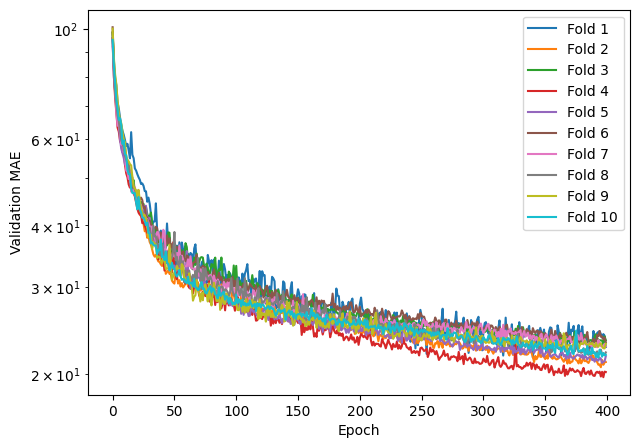

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
for r in fold_results:
    plt.plot(r['val_losses'], label=f"Fold {r['fold'] + 1}")
plt.xlabel('Epoch')
plt.ylabel('Validation MAE (meV/atom)')
plt.yscale('log')
plt.legend()
#plt.title('Validation loss per fold')
plt.savefig('validation-split.pdf', dpi=50, bbox_inches='tight')
plt.show()

# Generate uncertainties from out-of-fold predictions

Unlike the original train/val/test version -- where the reference dataset's predictions came from a single model that had already trained on the train+val portion of it -- every prediction here is out-of-fold: each material's residual comes from the one fold-model that never saw it during training. This gives a less biased basis for the interpolator.

In [ ]:
# label: uncertainty = ground-truth - prediction
uncertainties = oof_ground_truths - oof_predictions

# Standardize for better interpolation
uncert_mean  = uncertainties.mean()
uncert_std   = uncertainties.std()
uncert_scale = 1

uncertainties_std = (uncertainties - uncert_mean) * uncert_scale / uncert_std

# Check all labels are unique, otherwise you should rename them
if len(oof_labels) == len(set(oof_labels)):
    print('All labels are unique')
else:
    print('Error: some labels are duplicated')

# Generate dictionary with uncertainty data
uncertainty_values = {}
for idx in range(len(oof_labels)):
    uncertainty_values.update(
        {oof_labels[idx]: float(uncertainties_std[idx])}
    )
uncertainty_data = {
    'uncertainty_values': uncertainty_values,
    'uncert_mean':        uncert_mean,
    'uncert_std':         uncert_std,
    'uncert_scale':       uncert_scale
}

# Dump the dictionary with numpy arrays to a JSON file
cld.save_json(uncertainty_data, files_names['uncertainty_data'])

## Optional: refit a final model on the full dataset

K-fold gives a robust performance estimate and `n_splits` separate models, but none of them trained on 100% of the data. If a single deployable model is needed afterward, this refits one using a small material-grouped hold-out purely for early-stopping monitoring (not evaluation -- that's what the CV loop above already did properly). This is its own standalone training run, so it can also be done in a fresh kernel session if you'd rather not risk any carryover from whichever fold ran last. Skip this cell if you only needed the CV performance estimate.

In [ ]:
def get_material_train_val_split(material_labels, val_ratio=0.1, seed=42):
    """Single grouped train/val split (not part of the CV loop) - used only
    for early-stopping monitoring when refitting on the full dataset.

    Args:
        material_labels (np.ndarray): Material label (first token of data.label) per graph.
        val_ratio        (float):     Fraction of unique materials held out for monitoring.
        seed              (int):      Random seed for reproducible split.

    Returns:
        tuple: (train_labels, val_labels) arrays of unique material labels.
    """
    unique_labels = np.unique(material_labels)

    rng = np.random.RandomState(seed)
    shuffled_labels = unique_labels.copy()
    rng.shuffle(shuffled_labels)

    n_val = max(1, int(round(val_ratio * len(unique_labels))))
    val_labels   = shuffled_labels[:n_val]
    train_labels = shuffled_labels[n_val:]
    return train_labels, val_labels


final_train_labels, final_val_labels = get_material_train_val_split(material_labels_all, val_ratio=0.1)

final_train_dataset = cld.get_datasets(final_train_labels, material_labels_all, dataset)
final_val_dataset   = cld.get_datasets(final_val_labels,   material_labels_all, dataset)

final_train_dataset_std, final_std_parameters = cld.standardize_dataset(
    final_train_dataset, transformation='inverse-quadratic'
)
final_val_dataset_std = cld.standardize_dataset_from_keys(
    [data.clone() for data in final_val_dataset], final_std_parameters
)

final_files_names = {
    'train_dataset_std': f'{target_folder}/final_train_dataset_std.pt',
    'val_dataset_std':   f'{target_folder}/final_val_dataset_std.pt',
    'std_parameters':    f'{target_folder}/final_standardized_parameters.json',
    'model':             f'{target_folder}/final_model.pt'
}
torch.save(final_train_dataset_std, final_files_names['train_dataset_std'])
torch.save(final_val_dataset_std,   final_files_names['val_dataset_std'])
cld.save_json(final_std_parameters, final_files_names['std_parameters'])

final_target_factor = np.array(final_std_parameters['target_std']) / final_std_parameters['scale']

final_train_loader = DataLoader(final_train_dataset_std, batch_size=batch_size, shuffle=False, pin_memory=True)
final_val_loader   = DataLoader(final_val_dataset_std,   batch_size=batch_size, shuffle=False, pin_memory=True)

n_node_features = final_train_dataset_std[0].num_node_features

if os.path.exists(final_files_names['model']):
    os.remove(final_files_names['model'])

final_model = clm.load_model(n_node_features, dropout, device, model_name=final_files_names['model'], mode='train')

final_optimizer      = torch.optim.Adam(final_model.parameters(), lr=learning_rate)
final_criterion       = torch.nn.MSELoss()

final_train_losses = []
final_val_losses   = []
for epoch in range(n_epochs):
    train_loss, _, _ = clm.train(final_model, final_criterion, final_train_loader,
                                 final_target_factor, final_std_parameters['target_mean'],
                                 final_optimizer)
    val_loss,   _, _ = clm.test(final_model, final_criterion, final_val_loader,
                                 final_target_factor, final_std_parameters['target_mean'])

    train_loss = np.sum(np.sqrt(train_loss) * final_target_factor)
    val_loss   = np.sum(np.sqrt(val_loss)   * final_target_factor)

    final_train_losses.append(train_loss)
    final_val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch: {epoch + 1}, Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}')

final_model = clm.load_model(n_node_features, dropout, device, model_name=final_files_names['model'], mode='eval')
cld.losses_plot(train_losses=final_train_losses, val_losses=final_val_losses, to_log=True)

print(f"Final model saved to {final_files_names['model']}")
print(f'Expected performance (from k-fold CV above): {fold_maes.mean():.4f} +/- {fold_maes.std():.4f}')